# 7.9 反向传播算法实战

本节我们将利用前面介绍的多层全连接网络的梯度推导结果，直接利用 Python 循环计
算每一层的梯度，并按着梯度下降算法手动更新。由于 TensorFlow 具有自动求导功能，我
们选择没有自动求导功能的 Numpy 实现网络，并利用 Numpy 手动计算梯度并手动更新网
络参数。
需要注意的是，本章推导的梯度传播公式是针对于多层全连接层，只有 Sigmoid 一种
激活函数，并且损失函数为均方误差函数的网络类型。对于其它类型的网络，比如激活函
数采用 ReLU，损失函数采用交叉熵的网络，需要重新推导梯度传播表达式，但是方法是
一样。正是因为手动推导梯度的方法局限性较大，在实践中采用极少，更多的是利用自动
求导工具计算。
我们将实现一个 4 层的全连接网络，来完成二分类任务。网络输入节点数为 2，隐藏
层的节点数设计为：25、50和25，输出层两个节点，分别表示属于类别 1 的概率和类别 2
的概率，如图 7.13 所示。这里并没有采用 Softmax 函数将网络输出概率值之和进行约束，
而是直接利用均方误差函数计算与 One-hot 编码的真实标签之间的误差，所有的网络激活
函数全部采用 Sigmoid 函数，这些设计都是为了能直接利用我们的梯度传播公式。

## 7.9.1 数据集

这里通过 scikit-learn 库提供的便捷工具生成 2000 个线性不可分的 2 分类数据集，数据
的特征长度为 2，采样出的数据分布如图 7.14 所示，所有的红色点为一类，所有的蓝色点
为一类，可以看到每个类别数据的分布呈月牙状，并且是是线性不可分的，无法用线性网
络获得较好效果。为了测试网络的性能，我们按着7: 3比例切分训练集和测试集，其中
2000 ∙ 0 3 = 600个样本点用于测试，不参与训练，剩下的 1400 个点用于网络的训练。

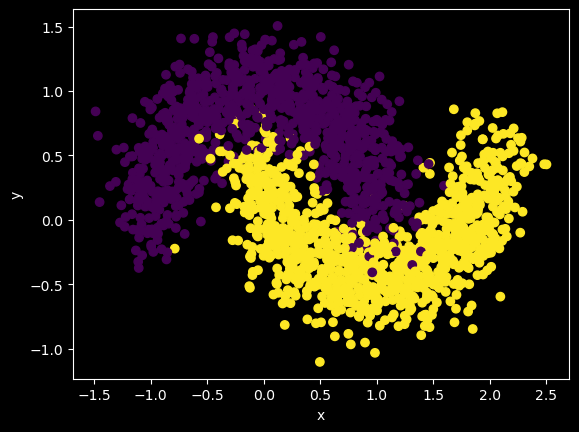

In [17]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

N_SAMPLES = 2000  # 采样点数
TEST_SIZE = 0.3  # 测试数量比例
# 利用工具函数直接生成数据集
X, y = make_moons(n_samples=2000, noise=0.2, random_state=100)
plt.scatter(X[:, 0], X[:, 1], c=y, label="数据集")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42)
print("训练集大小：", X_train.shape, y_train.shape)
print("测试集大小：", X_test.shape, y_test.shape)

训练集大小： (1400, 2) (1400,)
测试集大小： (600, 2) (600,)


## 7.9.2 网络层  
通过新建类 Layer 实现一个网络层，需要传入网络层的输入节点数、输出节点数、激
活函数类型等参数，权值 weights 和偏置张量 bias 在初始化时根据输入、输出节点数自动
生成并初始化。代码如下：

In [19]:
class Layer:
    # 全连接网络层
    def __init__(self, n_input, n_neurons, activation=None, weights=None, bias=None):
        """
        :param n_input: 输入节点数
        :param n_neurons: 输出节点数
        :param activation: 激活函数类型
        :param weights: 权值张量，默认内部类生成
        :param bias: 偏置张量，默认内部类生成

        """
        # 通过正态分布初始化网络权值，初始化非常重要，不合适的初始化将导致网络不收敛
        self.weights = weights if weights is not None else np.random.randn(
            n_input, n_neurons) * np.sqrt(1 / n_neurons)
        self.bias = bias if bias is not None else np.random.rand(
            n_neurons) * 0.1
        self.activation = activation  # 激活函数类型，如'sigmoid'、'tanh'或'linear'
        self.last_activation = None  # 激活函数的输出值 o
        self.error = None  # 用于计算梯度的误差项
        self.delta = None  # 记录当前层的 delta 变量，用于计算梯度

    # 网络层的前向传播函数实现如下，其中 last_activation 变量用于保存当前层的输出值：
    def activate(self, x):
        # 向前传播函数
        r = np.dot(x, self.weights) + self.bias  # x @ w + b
        self.last_activation = self._apply_activation(r)
        return self.last_activation

    # 上述代码中的 self._apply_activation 函数实现了不同类型的激活函数的前向计算过程，尽管
    # 此处我们只使用 Sigmoid 激活函数一种。代码如下：

    def _apply_activation(self, r):
        # 计算激活函数的输出
        if self.activation is None:
            return r  # 无激活函数
        # ReLU激活函数
        elif self.activation == 'relu':
            return np.maximum(r, 0)
        # tanh激活函数
        elif self.activation == 'tanh':
            return np.tanh(r)
        # sigmoid激活函数
        elif self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-r))  # Sigmoid激活函数
        return r

    # 针对于不同类型的激活函数，它们的导数计算实现如下：
    def apply_activation_derivative(self, r):
        # 计算激活函数的导数
        if self.activation is None:
            return np.ones_like(r)  # 无激活函数的导数为1
        # ReLU激活函数的导数
        elif self.activate == 'relu':
            grad = np.array(r, copy=True)
            grad[r > 0] = 1.
            grad[r <= 0] = 0.
            return grad
        # tanh激活函数的导数
        elif self.activation == 'tanh':
            return 1 - np.tanh(r) ** 2  # tanh激活函数的导数
        # sigmoid激活函数的导数
        elif self.activation == 'sigmoid':
            return r * (1 - r)  # sigmoid激活函数的导数
        return r


可以看到，Sigmoid 函数的导数实现为𝑟 (1 − 𝑟)，其中𝑟即为𝜎(𝑧)。

## 7.9.3 网络模型
创建单层网络类后，我们实现网络模型的 NeuralNetwork 类，它**内部维护各层的网络层** Layer 类对象，可以通过 add_layer 函数追加网络层，实现创建不同结构的网络模型目
的。代码如下：

In [22]:
class NeuralNetwork:
    # 神经网络大类
    def __init__(self):
        self._layers = []  # 网络层对象列表

    def add_layer(self, layer):
        #  追加网络层
        self._layers.append(layer)

    # 网络的前向传播只需要循环调各个网络层对象的前向计算函数即可，代码如下
    def feed_forward(self, X):
        # 向前传播
        for layer in self._layers:
            X = layer.activation(X)
        return X

    def backpropagation(self, X, y, learning_rate):
        # 反向传播算法实现
        # 向前计算，得到输出值
        output = self.feed_forward(X)
        for i in reversed(range(len(self._layers))):  # 反向循环
            layer = self._layers[i]  # 得到层对象
            if layer == self._layers[-1]:  # 如果当前层为输出层
                layer.error = y - output  # 对于二分类任务均方差的导数
                # 关键步骤：计算最后一层的 delta，参考输出层的梯度公式
                layer.delta = layer.error * layer.apply_activation_derivative(output)
            else:  # 如果是隐藏层
                next_layer = self._layers[i + 1]  # 得到下一层的对象
                layer.error = np.dot(next_layer.weight, next_layer.delta)
                # 关键步骤：计算隐藏层的 delta，参考隐藏层的梯度公式
                layer.delta = layer.error * layer.apply_activation_derivative(layer.last_activation)

        for i in range(len(self._layers)):
            layer = self._layers[i]
            # o_i 为上一网络层的输出
            o_i = np.atleast_2d(X if i == 0 else self._layers[i - 1].last_activation)
            # 梯度下降算法，delta 是公式中的负数，故这里用加号
            layer.weights += layer.delta * o_i.T * learning_rate

    def train(self, X_train, X_test, y_train, y_test, learning_rate, max_epochs):
        # 网络训练函数
        # one-hot 编码
        y_onehot = np.zeros((y_train[0], 2))
        y_onehot[np.arange(y_train.shape[0]), y_train] = 1
        # 将 One-hot 编码后的真实标签与网络的输出计算均方误差，并调用反向传播函数更新网络
        # 参数，循环迭代训练集 1000 遍即可。代码如下：
        mses = []
        for i in range(max_epochs):  # 训练1000个epoch
            for j in range(len(X_train)):  # 每次训练一个样本
                self.backpropagation(X_train[j], y_onehot[j], learning_rate)
                if i % 10 == 0:
                    # 打印出 MSE Loss
                    mse = np.mean(np.square(y_onehot - self.feed_forward(X_train)))
                    mses.append(mse)
                    print('Epoch: #%s, MSE: %f' % (i, float(mse)))
                    # 统计并打印准确率
                    print('Accuracy: %.2f%%' % (self.accuracy(self.predict(X_test), y_test.flatten()) * 100))

        return mses

根据图 7.13 的网络结构配置，利用 NeuralNetwork 类创建网络对象，并添加 4 层全连
接层，代码如下：

In [23]:
nn = NeuralNetwork()  # 实例化网络类
nn.add_layer(Layer(2, 25, "sigmoid"))  # 隐藏层1, 2 => 25
nn.add_layer(Layer(25, 50, "sigmoid"))  # 隐藏层2, 25 => 50
nn.add_layer(Layer(50, 25, "sigmoid"))  # 隐藏层3, 50 => 25
nn.add_layer(Layer(50, 25, "sigmoid"))  # 输出层, 25 => 2

因此，在 backpropagation 函数中，反向计算每层的𝛿变量，并根据梯度公式计算每层
参数的梯度值，按着梯度下降算法完成一次参数的更新。

## 7.9.4 网络训练
这里的二分类任务网络设计为两个输出节点，因此需要将真实标签𝑦进行 One-hot 编码，代码如下：

## 7.9.5 网络性能
我们将每个 Epoch 的训练损失ℒ值记录下，并绘制为曲线，如图 7.15 所示
在训练完 1000 个 Epoch 后，在测试集 600 个样本上得到的准确率为：
Epoch: #990, MSE: 0.024335
Accuracy: 97.67%

可以看到，通过手动计算梯度公式并手动更新网络参数的方式，我们在简单的二分类任务
上也能获得了较低的错误率。通过精调网络超参数等技巧，还可以获得更好的网络性能。
在每个 Epoch 中，我们在测试集上完成一次准确度测试，并绘制成曲线，如图 7.16
所示。可以看到，随着 Epoch 的进行，模型的准确率稳步提升，开始阶段提升较快，后续
提升较为平缓。

通过这个基于 Numpy 手动计算梯度而实现的二分类全连接网络，相信读者朋友们能够
更加深刻地体会到深度学习框架在算法实现中的角色。没有诸如 TensorFlow 这些框架，我
们同样能够实现复杂的神经网络，但是灵活性、稳定性、开发效率和计算效率都较差，基
于这些深度学习框架进行算法设计与训练，将大大提升算法开发人员的工作效率。同时我
们也能意识到，框架只是一个工具，更重要的是，我们对算法本身的理解，这才是算法开
发者最重要的能力。